In [1]:
from alldata import PresentationMapper, DataAggregator
from gaze import GazeData

In [2]:
import pandas as pd
df_pos = pd.read_csv("data/sentence_position.csv") # with pilot 2 index
df_pos.head() 

,real_index,part_nr,line_idx,text,top,bottom,left,right
0,0,1,0,Il est 4 heures du matin et John est sur le po...,323,368,137,1775
1,0,1,1,lorsqu'il entend des coups de feu.,411,456,514,1398
2,0,2,0,Il sursaute de son lit et regarde par sa fenêtre.,579,624,319,1593
3,1,1,0,Il est 4 heures du matin et Mike s'apprête à a...,191,236,215,1697
4,1,1,1,lorsque soudain il entend un homme crier 'Adie...,279,324,176,1736


In [3]:
mapper2 = PresentationMapper("data/sentences.js", "data/pilot_2/sentence_order_gaze_2.csv")

gaze1 = GazeData("data/pilot_1/pilot1_gaze_2026-06-22_17-40-03 (1).csv")
gaze2 = GazeData("data/pilot_2/gaze_2.csv")
gaze3 = GazeData("data/pilot_3/gaze_2026-06-24_18-05-11.csv")

order1 = "data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv"
order2 = "data/pilot_2/sentence_order_gaze_2.csv"
order3 = "data/pilot_3/sentence_order_gaze_2026-06-24_18-05-11.csv"


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_2/sentence_order_gaze_2.csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                                                                                             first  real_index
                  0                                                                                                                                                                        Eva planifie un city-trip à San Francisco.          66

In [4]:
aggregator = DataAggregator(
    gazedata=[gaze1, gaze2, gaze3],
    real_order_path="data/sentences.js",
    exp_order_paths=[order1, order2, order3],
    df_pos=df_pos,
    sentence_metadata_path="data/combined_valid_sentences.xlsx"
)

# Per participant stats with real_index
df_all = aggregator.compute_gaze_fix_stats()

# Aggregated across participants
df_aggregated = aggregator.aggregate_by_sentence()

[load_sentence_metadata] Loaded 97 sentences

[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                            first  real_index
                  0 Simon est en train de courir pour attraper son bus lorsque son téléphone sonne. Une voix glaciale lui dit qu'un de ses proches a eu un accident.          13
                  1                                 Mik

In [5]:
df_aggregated.head()

,real_index,mean_gaze_samples,std_gaze_samples,mean_fixations,std_fixations,mean_horizontal_fixations,std_horizontal_fixations,n_participants,groupUnc,groupRes,groupVal
0,0,4.000000,5.291503,0.000000,0.00000,0.000000,0.00000,3,high unc conditions,low res conditions,neg conditions
1,1,5.333333,7.571878,0.333333,0.57735,0.000000,0.00000,3,high unc conditions,high res conditions,neg conditions
2,2,0.666667,1.154701,0.000000,0.00000,0.000000,0.00000,3,low unc conditions,high res conditions,pos conditions
3,3,2.000000,3.464102,0.000000,0.00000,0.000000,0.00000,3,high unc conditions,low res conditions,pos conditions
4,4,70.000000,65.574385,0.333333,0.57735,0.666667,0.57735,3,low unc conditions,low res conditions,pos conditions


In [6]:
# Get data for participant 0
df_p1 = df_all[df_all["participant"] == 0]

# Get data for participant 1
df_p2 = df_all[df_all["participant"] == 1]

In [7]:
df_all.head()

,presentation,gaze_samples,fixations,horizontal_fixations,real_index,participant,groupUnc,groupRes,groupVal
0,0,18,1,0,13,0,high unc conditions,low res conditions,neg conditions
1,1,50,0,0,33,0,high unc conditions,low res conditions,neg conditions
2,2,86,0,1,77,0,high unc conditions,high res conditions,neg conditions
3,3,17,0,0,81,0,low unc conditions,low res conditions,neg conditions
4,4,0,0,0,18,0,high unc conditions,high res conditions,neg conditions


# plots !

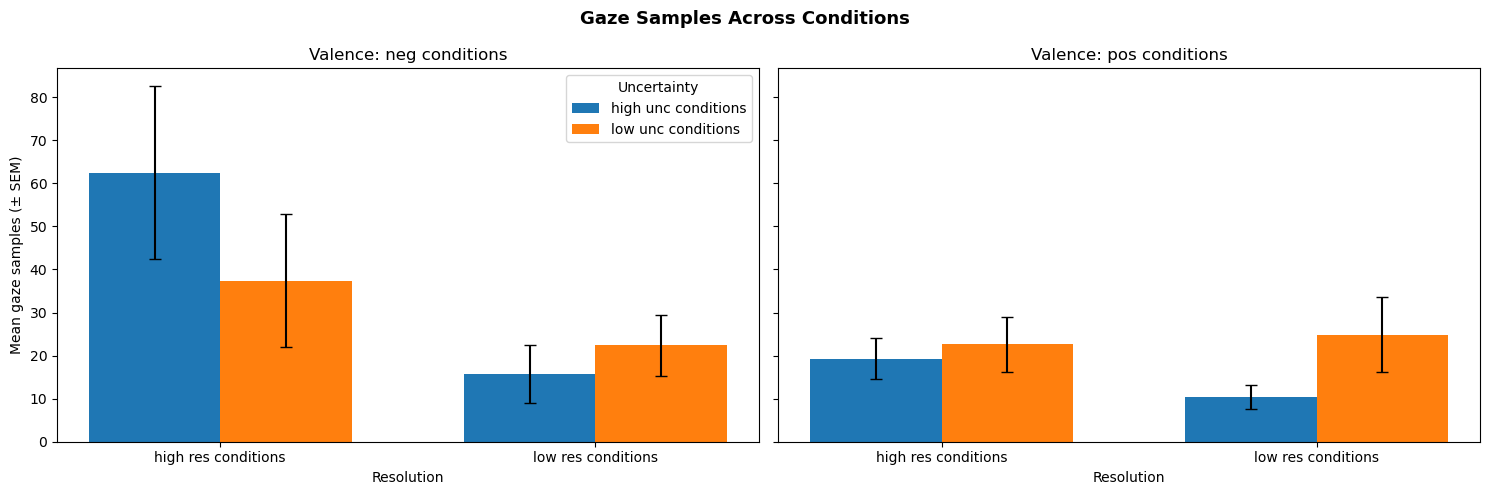

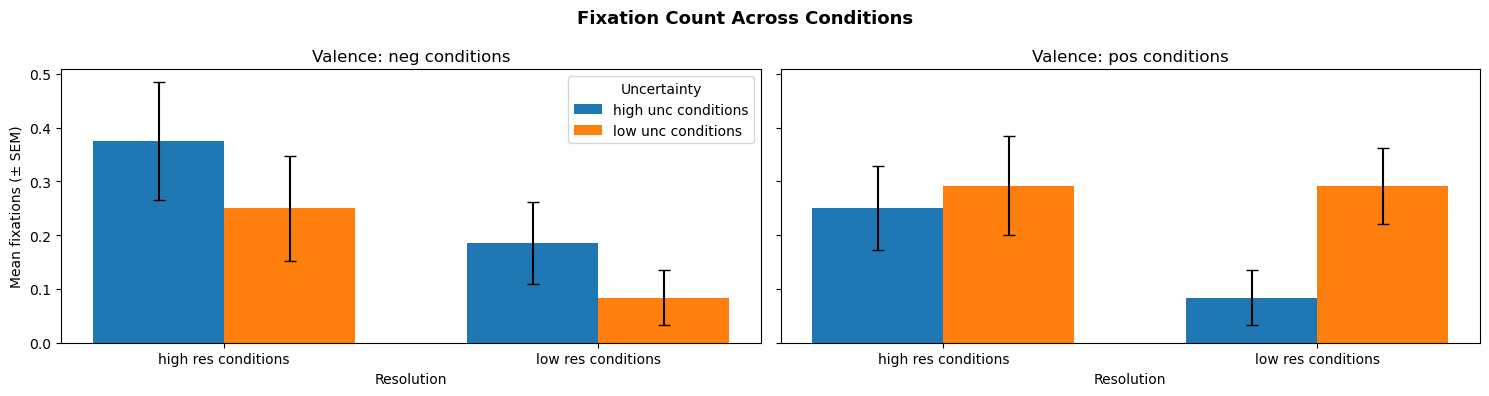

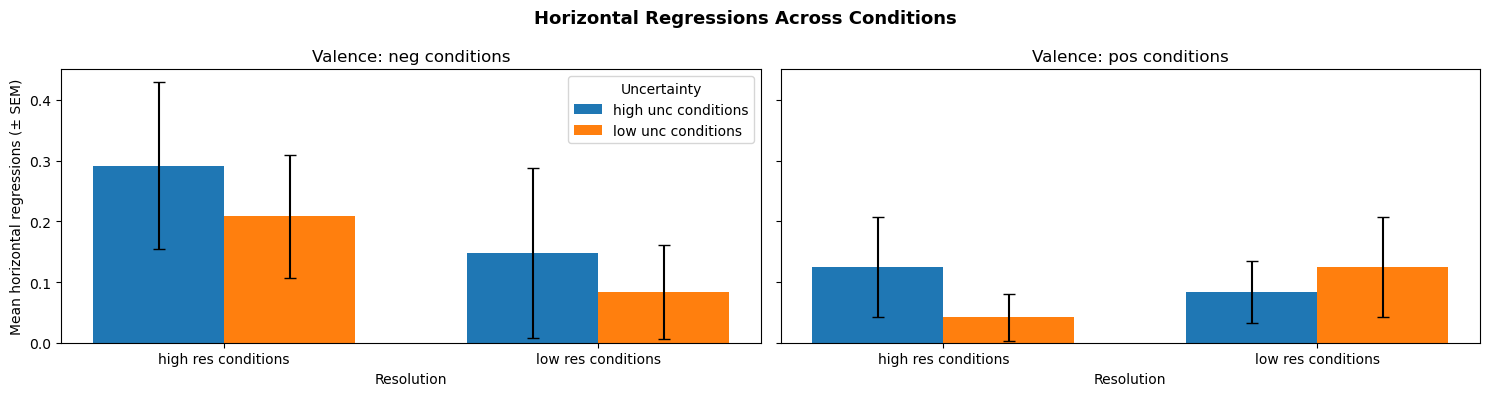

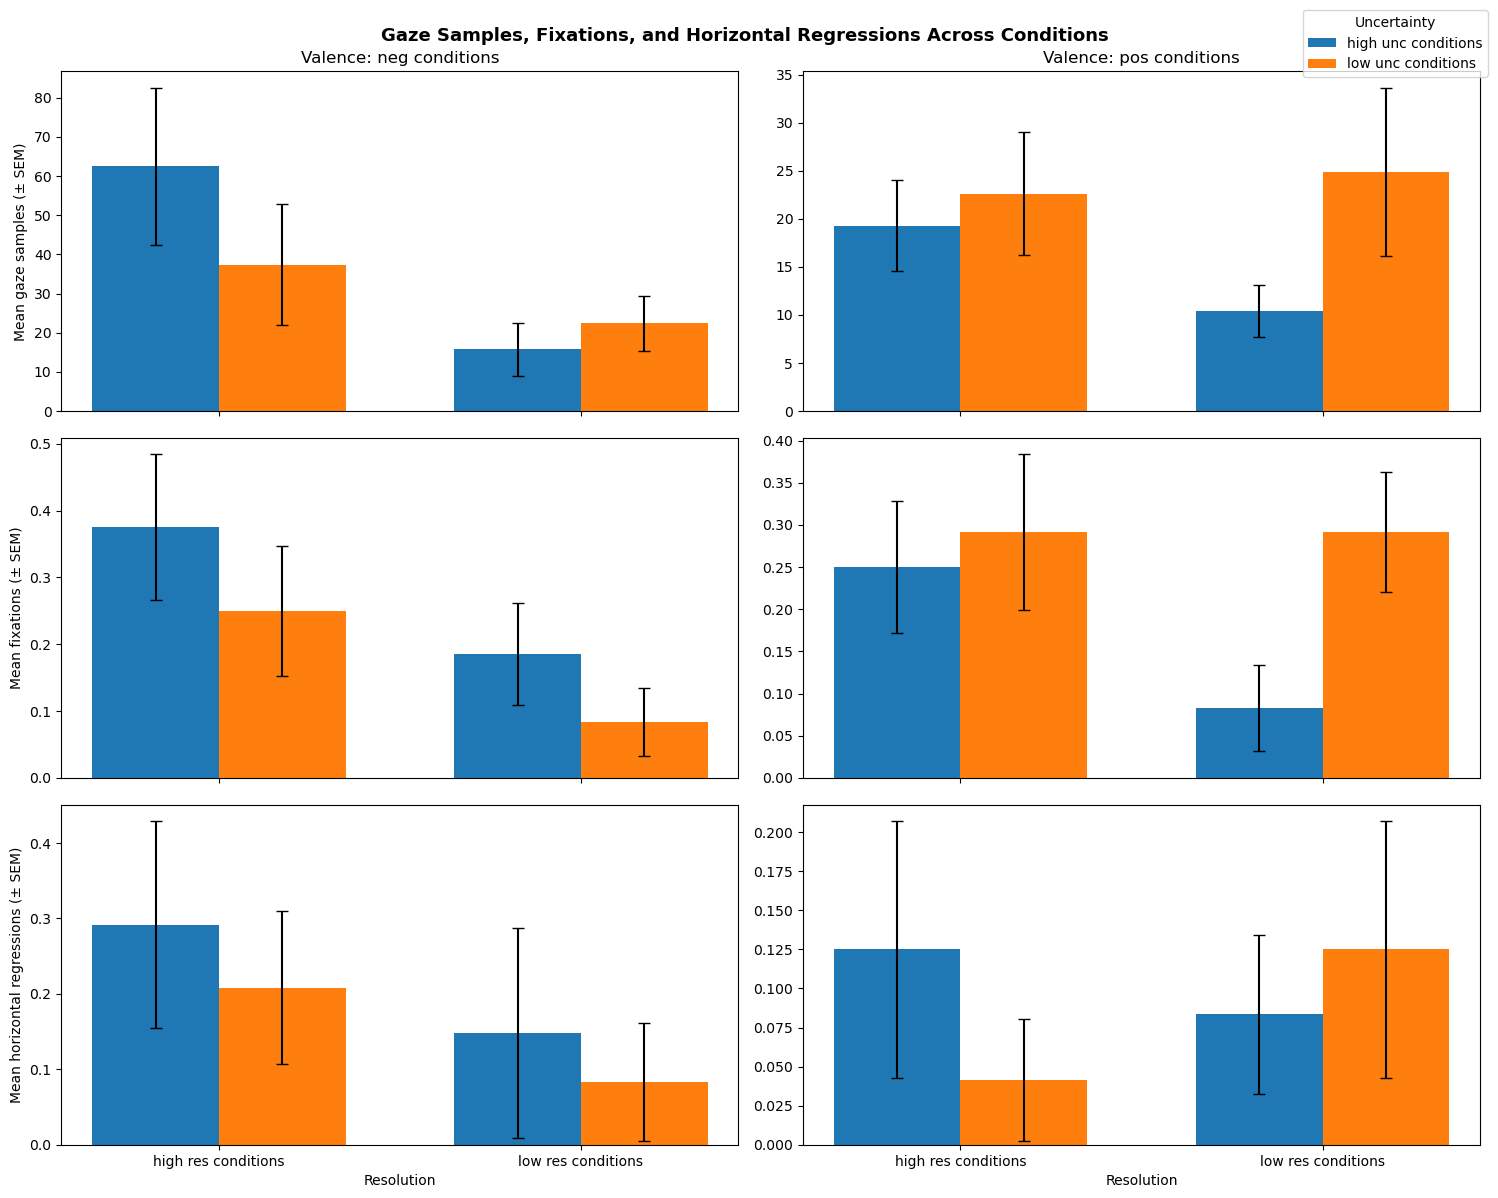

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVING_PATH = "data/figures/"

# Use the aggregated output already computed in the notebook
# Expected columns: real_index, mean_gaze_samples, std_gaze_samples,
# mean_fixations, std_fixations, n_participants, groupUnc, groupRes, groupVal

df = df_aggregated.copy()

required_cols = [
    "real_index",
    "mean_gaze_samples",
    "std_gaze_samples",
    "mean_fixations",
    "std_fixations",
    "mean_horizontal_fixations",
    "std_horizontal_fixations",
    "n_participants",
    "groupUnc",
    "groupRes",
    "groupVal",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in df_aggregated: {missing}")

# Collapse multiple sentence-level rows to one summary row per condition combination
# so the grouped bar chart can be built without duplicate resolution labels.
df = df.dropna(subset=["groupUnc", "groupRes", "groupVal"]).copy()
for col in ["groupUnc", "groupRes", "groupVal"]:
    df[col] = df[col].astype(str)

plot_df = (
    df.groupby(["groupVal", "groupUnc", "groupRes"], as_index=False)
    .agg(
        mean_gaze_samples=("mean_gaze_samples", "mean"),
        std_gaze_samples=("mean_gaze_samples", lambda s: s.std(ddof=0)),
        mean_fixations=("mean_fixations", "mean"),
        std_fixations=("mean_fixations", lambda s: s.std(ddof=0)),
        mean_horizontal_fixations=("mean_horizontal_fixations", "mean"),
        std_horizontal_fixations=("mean_horizontal_fixations", lambda s: s.std(ddof=0)),
        n_participants=("n_participants", "count"),
    )
    .fillna({"std_gaze_samples": 0, "std_fixations": 0, "std_horizontal_fixations": 0})
)

# Make the later plotting helpers use the cleaned summary data.
df = plot_df.copy()

UNC_ORDER = sorted(df["groupUnc"].unique())
RES_ORDER = sorted(df["groupRes"].unique())
VAL_ORDER = sorted(df["groupVal"].unique())

BAR_WIDTH = 0.35
COLORS = {
    "high": "#4C72B0",
    "low": "#DD8452",
    "none": "#55A868",
}


def use_sem(std, n):
    """Convert std to SEM given n_participants."""
    return std / np.sqrt(n)


def plot_metric_by_condition(
    df,
    mean_col,
    std_col,
    title,
    ylabel,
    error_type="sem",
    figsize=(15, 4.5),
):
    """Grouped bar chart: x = groupRes, hue = groupUnc, one subplot per groupVal."""
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)

            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants) if error_type == "sem" else stds

            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# Primary plot: gaze samples across conditions
fig_gaze = plot_metric_by_condition(
    df,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig(SAVING_PATH + "gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# Secondary plot: fixations across conditions
fig_fix = plot_metric_by_condition(
    df,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig(SAVING_PATH + "fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Tertiary plot: horizontal (within-line regression) fixations across conditions
fig_horiz = plot_metric_by_condition(
    df,
    mean_col="mean_horizontal_fixations",
    std_col="std_horizontal_fixations",
    title="Horizontal Regressions Across Conditions",
    ylabel="Mean horizontal regressions (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_horiz.savefig(SAVING_PATH + "horizontal_fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Combined overview for one figure
fig_combined, axes = plt.subplots(3, len(VAL_ORDER), figsize=(15, 12), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
        ("mean_horizontal_fixations", "std_horizontal_fixations", "Mean horizontal regressions (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants)
            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_ylim(bottom=0)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 2:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(),
    title="Uncertainty",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
)
fig_combined.suptitle(
    "Gaze Samples, Fixations, and Horizontal Regressions Across Conditions",
    fontsize=13,
    fontweight="bold",
)
fig_combined.tight_layout()
fig_combined.savefig(SAVING_PATH + "combined_gaze_fixations_horizontal_by_condition.png", dpi=200, bbox_inches="tight")

plt.show()

KeyError: "Label(s) ['mean_gaze_samples'] do not exist"

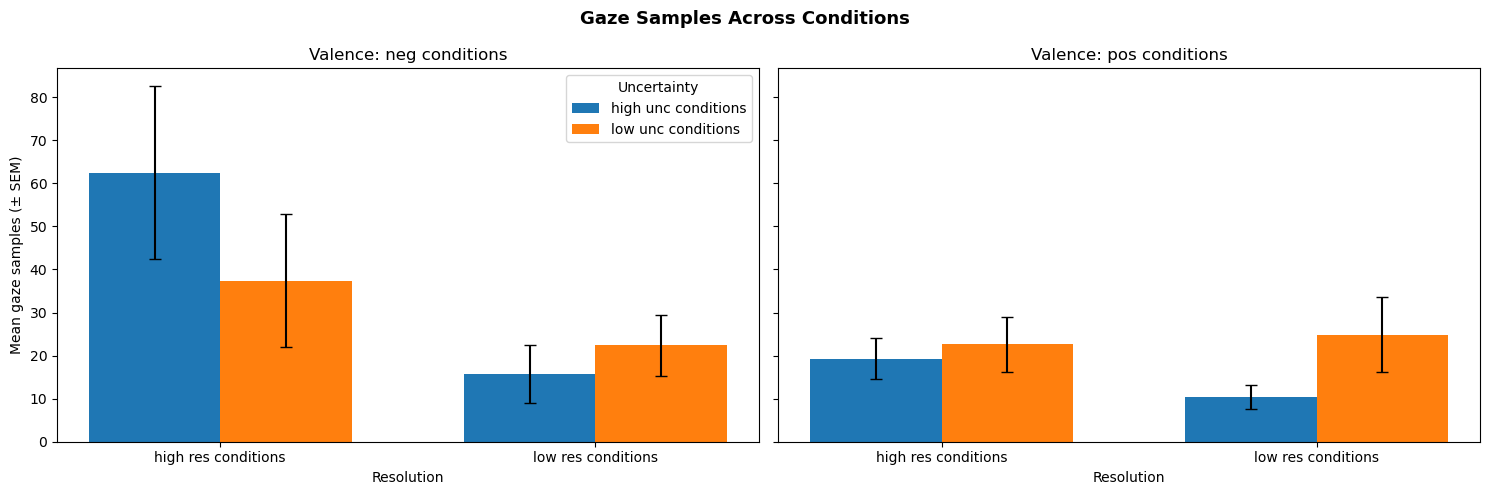

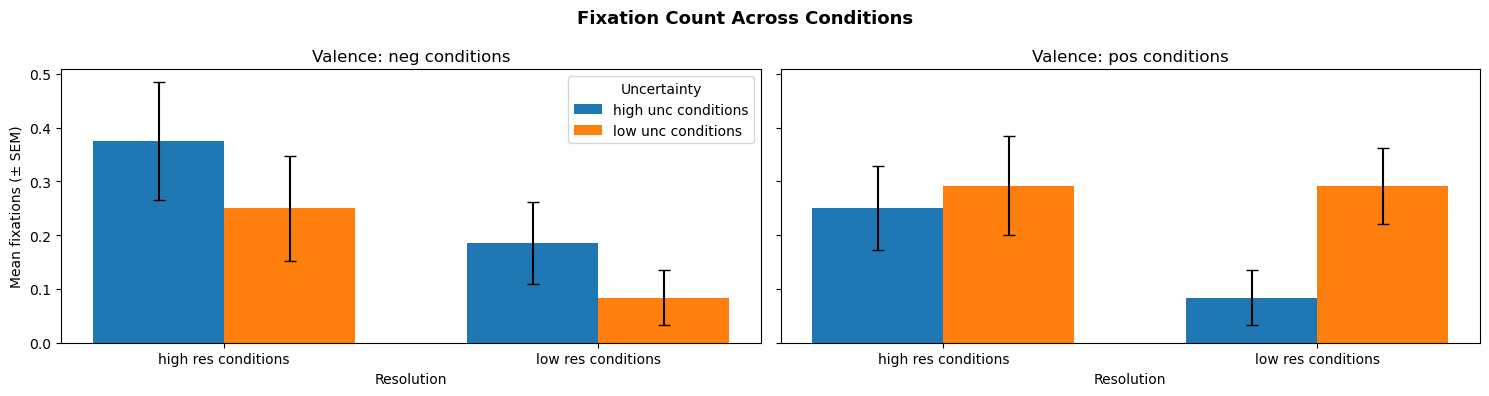

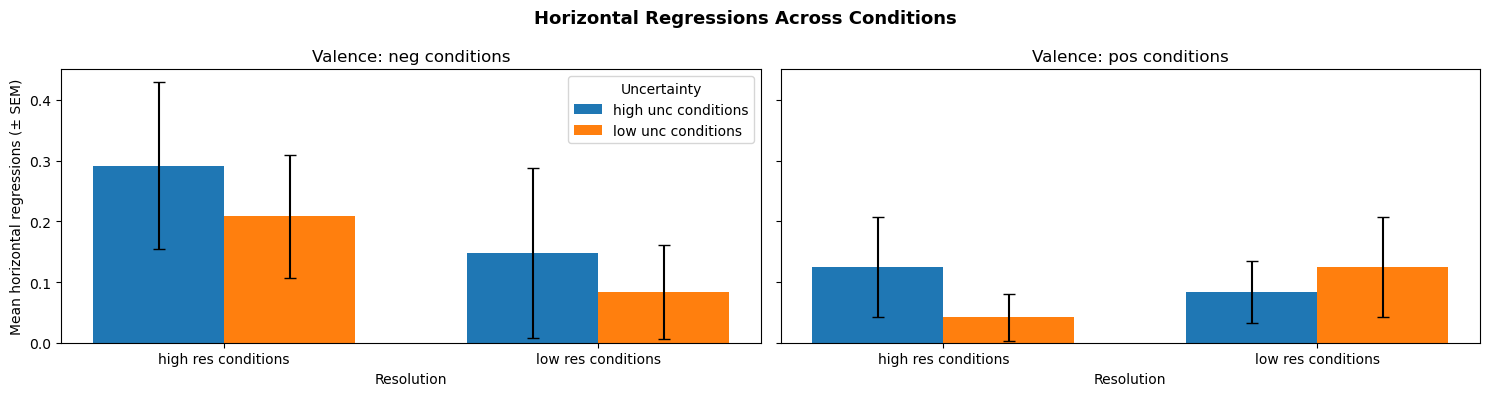

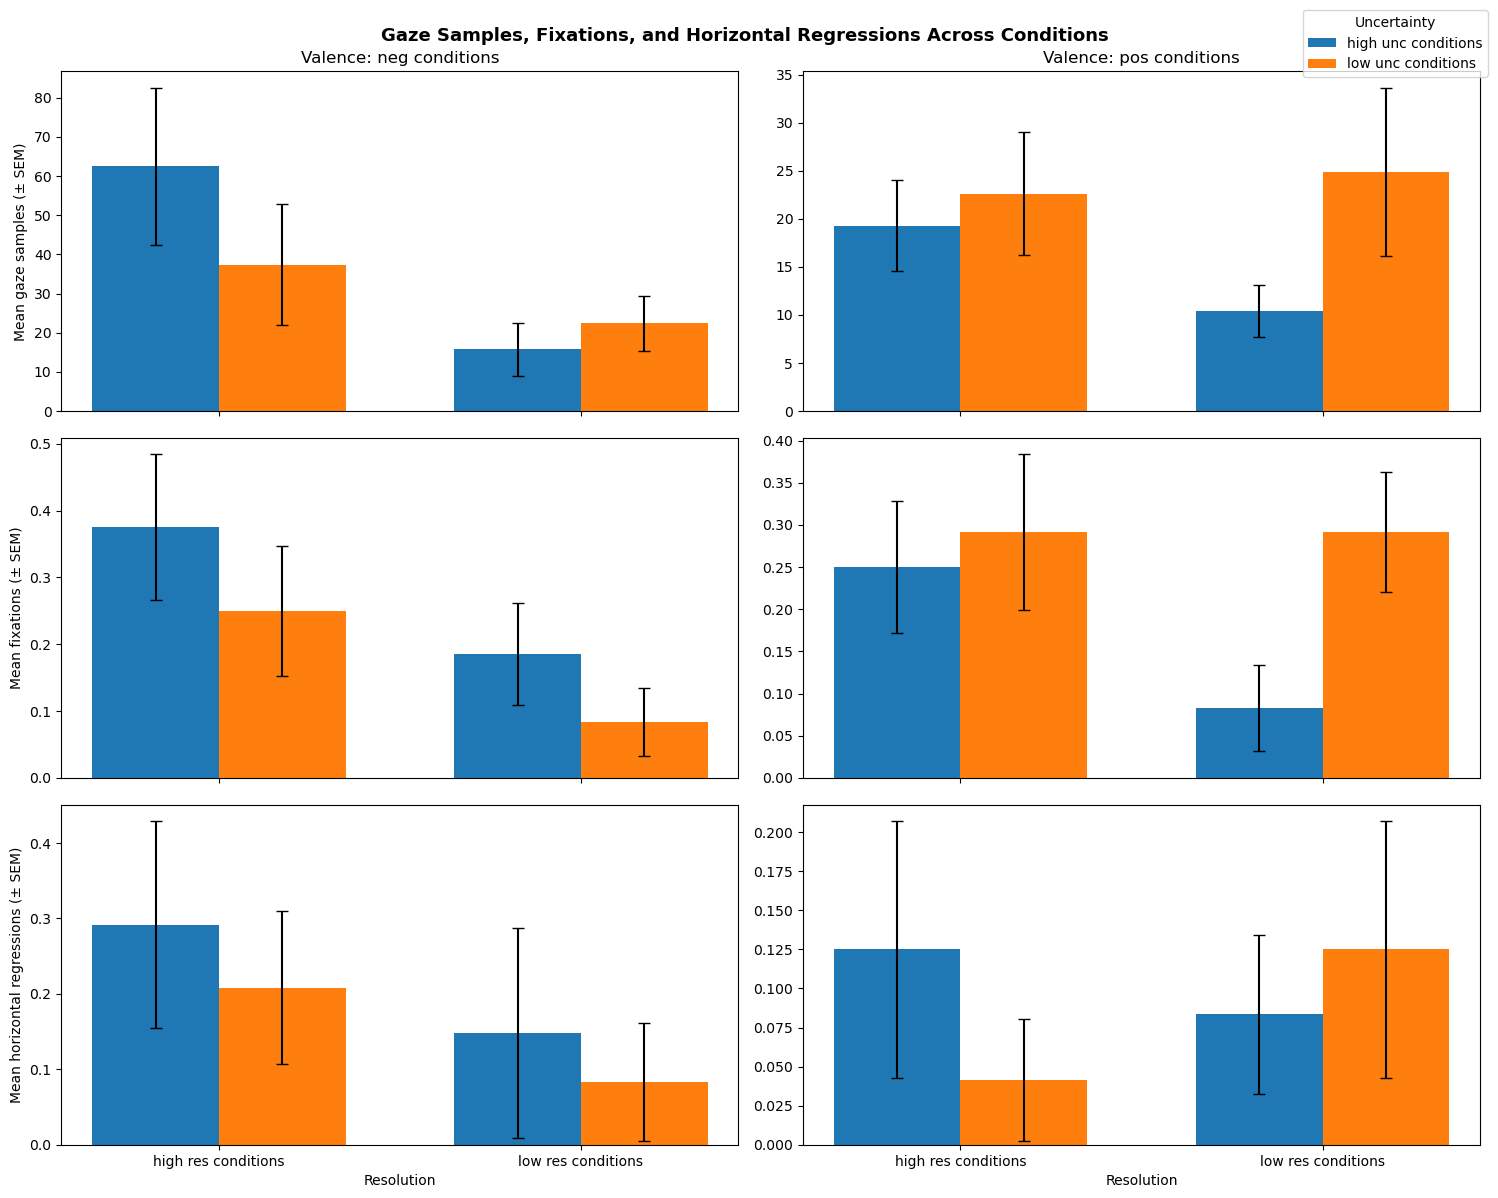

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SAVING_PATH = "data/figures/"
GROUP_COLS = ["groupVal", "groupUnc", "groupRes"]
METRICS = [
    ("gaze_samples", "Mean gaze samples"),
    ("fixations", "Mean fixations"),
    ("horizontal_fixations", "Mean horizontal regressions"),
]
COLORS = {"high": "#4C72B0", "low": "#DD8452", "none": "#55A868"}
BAR_WIDTH = 0.35


def plot_participant(df_p, participant_id, saving_path=SAVING_PATH):
    """One figure per participant: rows = metrics, cols = groupVal."""
    val_order = sorted(df_p["groupVal"].unique())
    unc_order = sorted(df_p["groupUnc"].unique())
    res_order = sorted(df_p["groupRes"].unique())
    x = np.arange(len(res_order))

    fig, axes = plt.subplots(len(METRICS), len(val_order), figsize=(15, 12), sharex="col")

    for row, (metric, ylabel) in enumerate(METRICS):
        stats = df_p.groupby(GROUP_COLS)[metric].agg(["mean", "std"]).reset_index()

        for col, val in enumerate(val_order):
            ax = axes[row, col]
            sub = stats[stats["groupVal"] == val]

            for i, unc in enumerate(unc_order):
                rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(res_order)
                offset = (i - 0.5) * BAR_WIDTH
                ax.bar(
                    x + offset, rows["mean"], BAR_WIDTH,
                    yerr=rows["std"].fillna(0), capsize=4,
                    label=unc if row == 0 and col == 0 else None,
                    color=COLORS.get(unc, None),
                )

            ax.set_xticks(x)
            ax.set_xticklabels(res_order)
            ax.set_ylim(bottom=0)
            if row == 0:
                ax.set_title(f"Valence: {val}")
            if row == len(METRICS) - 1:
                ax.set_xlabel("Resolution")
            if col == 0:
                ax.set_ylabel(f"{ylabel} (± SD)")

    fig.legend(*axes[0, 0].get_legend_handles_labels(), title="Uncertainty",
               loc="upper right", bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"Gaze Metrics Across Conditions — Participant {participant_id}",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{saving_path}participant_{participant_id}_gaze_conditions.png",
                dpi=200, bbox_inches="tight")
    return fig


for pid in sorted(df_all["participant"].unique()):
    plot_participant(df_all[df_all["participant"] == pid], pid)

plt.show()